#### Importing  Required Libraries

In [1]:
import os

import pandas as pd 
import numpy as np 

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import LabelEncoder


from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import SGDRegressor

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

from sklearn.svm import SVR
from xgboost import XGBRegressor
import xgboost as xgb

import joblib

import warnings
warnings.filterwarnings('ignore')

##### Defining paths

In [2]:

CURR_WORK_DIR= os.getcwd()
BASE_PATH = os.path.dirname(CURR_WORK_DIR)
DATA_PATH = os.path.join(BASE_PATH, "data", "uae_used_cars_10k.csv")


In [3]:
df=pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(10000, 12)


,Make,Model,Year,Price,Mileage,Body Type,Cylinders,Transmission,Fuel Type,Color,Location,Description
0,toyota,camry,2016,47819,156500,Sedan,4,Automatic Transmission,Gasoline,Black,Dubai,"2016 toyota camry with Rear camera, Leather se..."
1,kia,sorento,2013,61250,169543,SUV,4,Automatic Transmission,Gasoline,Grey,Abu Dhabi,"2013 kia sorento with Sunroof, Adaptive cruise..."
2,mini,cooper,2023,31861,221583,Soft Top Convertible,4,Automatic Transmission,Gasoline,Grey,Dubai,"2023 mini cooper with Adaptive cruise control,..."
3,nissan,altima,2016,110322,69754,Sedan,4,Automatic Transmission,Gasoline,Red,Dubai,"2016 nissan altima with Rear camera, Adaptive ..."
4,toyota,land-cruiser-76-series,2020,139994,71399,Pick Up Truck,4,Manual Transmission,Gasoline,White,Dubai,2020 toyota land-cruiser-76-series with Adapti...


##### Describe data

In [4]:
print('Summary Statistics for numeric columns:')
display(df.describe())

Summary Statistics for numeric columns:


,Year,Price,Mileage
count,10000.000000,1.000000e+04,10000.000000
mean,2014.472800,2.452345e+05,155161.871700
std,5.790839,4.709773e+05,83681.858983
min,2005.000000,7.183000e+03,10006.000000
25%,2009.000000,5.035250e+04,82904.000000
50%,2014.000000,1.027660e+05,154370.500000
75%,2019.000000,2.312480e+05,227551.250000
max,2024.000000,1.468698e+07,299996.000000


In [5]:
print('Summary Statistics for non numeric columns:')
display(df.describe(include = object))

Summary Statistics for non numeric columns:


,Make,Model,Body Type,Cylinders,Transmission,Fuel Type,Color,Location,Description
count,10000,10000,10000,9895,10000,10000,10000,10000,10000
unique,65,488,13,8,2,4,17,16,9985
top,mercedes-benz,patrol,SUV,6,Automatic Transmission,Gasoline,White,Dubai,"2021 mercedes-benz s-class with Bluetooth, Nav..."
freq,1486,386,4607,3420,9626,9714,3355,7990,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Make          10000 non-null  object
 1   Model         10000 non-null  object
 2   Year          10000 non-null  int64 
 3   Price         10000 non-null  int64 
 4   Mileage       10000 non-null  int64 
 5   Body Type     10000 non-null  object
 6   Cylinders     9895 non-null   object
 7   Transmission  10000 non-null  object
 8   Fuel Type     10000 non-null  object
 9   Color         10000 non-null  object
 10  Location      10000 non-null  object
 11  Description   10000 non-null  object
dtypes: int64(3), object(9)
memory usage: 937.6+ KB


In [7]:
df.columns

Index(['Make', 'Model', 'Year', 'Price', 'Mileage', 'Body Type', 'Cylinders',
       'Transmission', 'Fuel Type', 'Color', 'Location', 'Description'],
      dtype='object')

##### Data Analysis

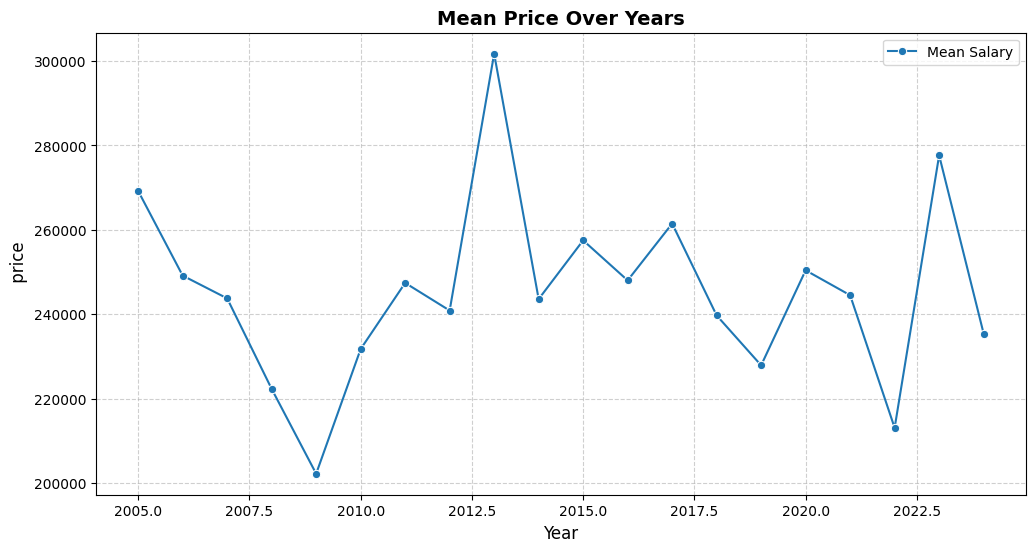

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df,x='Year',y='Price',ci=None,marker='o',estimator=np.mean,label='Mean Salary')
plt.title('Mean Price Over Years', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(' price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

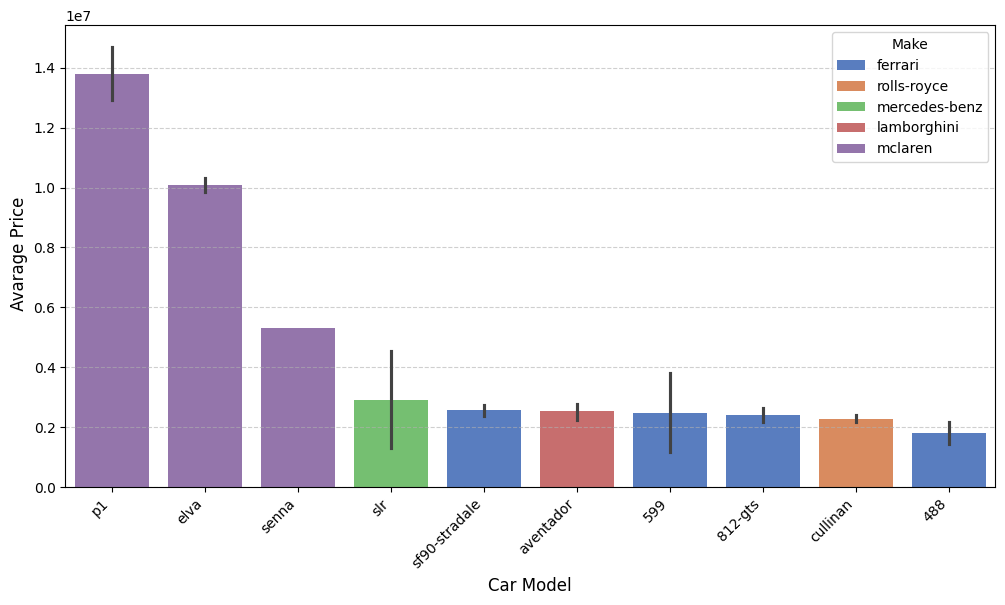

In [9]:
# Compute median price per car model
top_models = df.groupby("Model")["Price"].mean().nlargest(10)  # Get top 10 most expensive models

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df[df["Model"].isin(top_models.index)],  
    x="Model", 
    y="Price",
    hue='Make',
    estimator=np.mean, 
    order=top_models.index,  # Ensure correct sorting
    palette="muted"  # Color scheme for better visualization
)

plt.xlabel("Car Model", fontsize=12)
plt.ylabel(" Avarage Price", fontsize=12)
plt.xticks(rotation=45, ha="right")  # Rotate labels for better readability
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

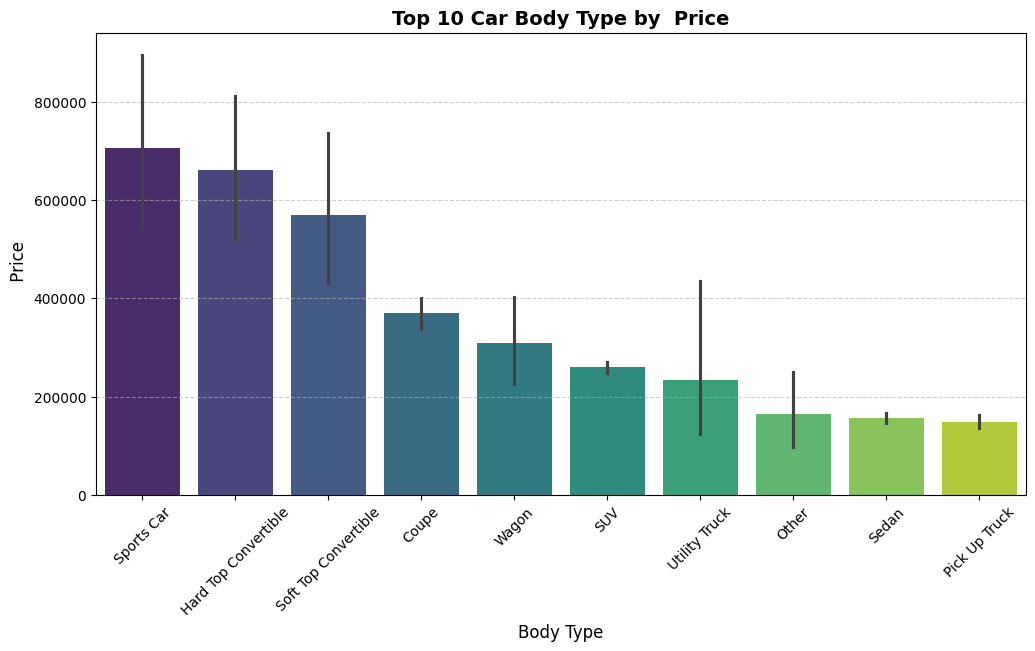

In [10]:
# Compute median price per car model
top_body_type = df.groupby("Body Type")["Price"].mean().nlargest(10)  # Get top 10 most expensive body

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df[df["Body Type"].isin(top_body_type.index)],  
    x="Body Type", 
    y="Price",
    estimator=np.mean, 
    order=top_body_type.index,  # Ensure correct sorting
    palette="viridis"# Color scheme for better visualization
)
# Title and Labels
plt.title("Top 10 Car Body Type by  Price", fontsize=14, fontweight="bold")
plt.xlabel("Body Type", fontsize=12)
plt.ylabel(" Price", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

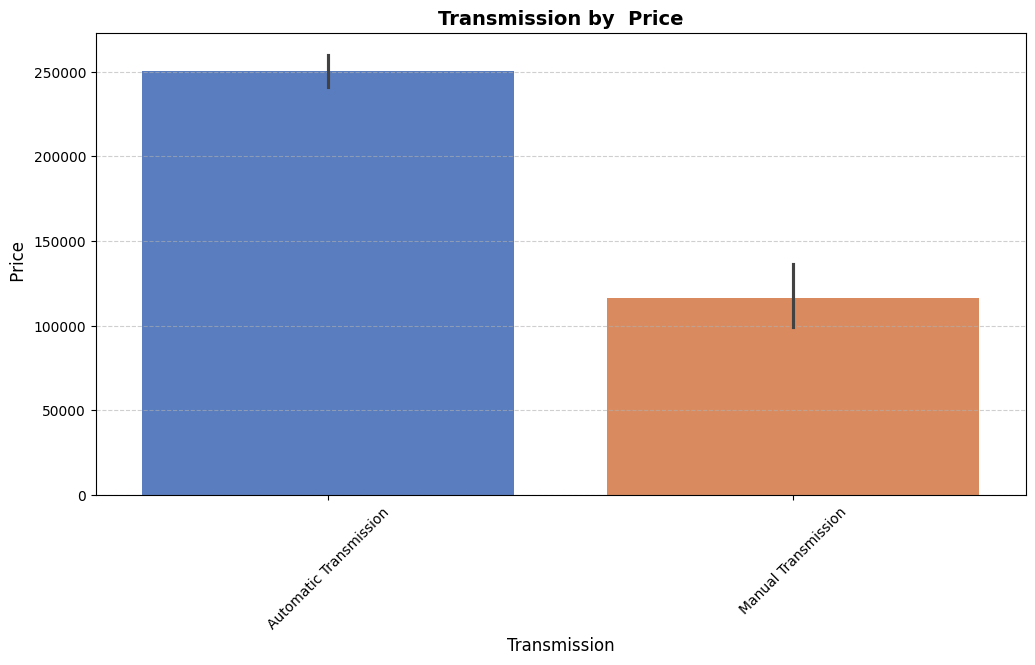

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df, x="Transmission", y="Price",estimator=np.mean,palette="muted")
# Title and Labels
plt.title("Transmission by  Price", fontsize=14, fontweight="bold")
plt.xlabel("Transmission", fontsize=12)
plt.ylabel(" Price", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

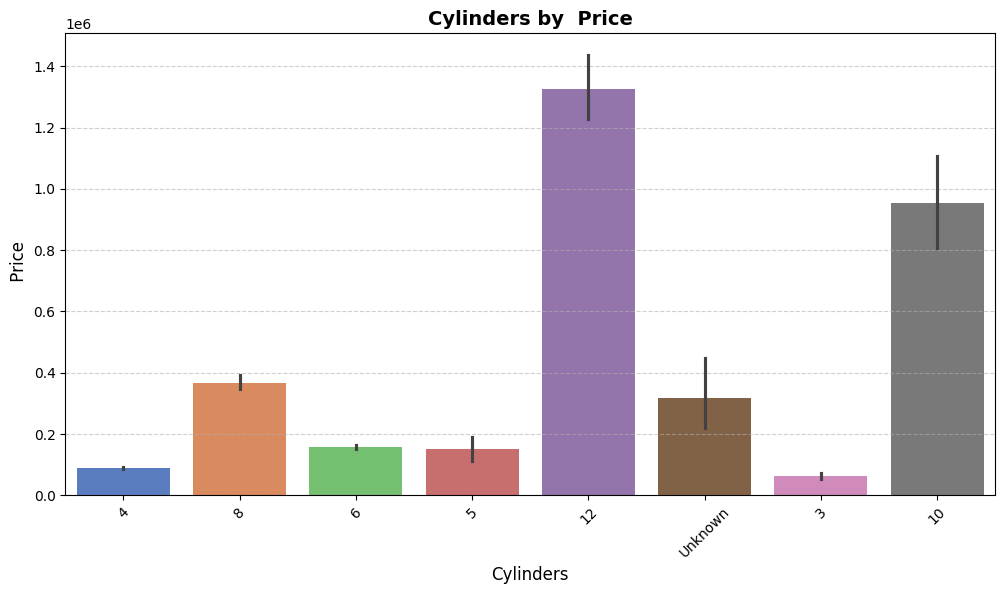

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df, x="Cylinders", y="Price",estimator=np.mean,palette='muted')
# Title and Labels
plt.title("Cylinders by  Price", fontsize=14, fontweight="bold")
plt.xlabel("Cylinders", fontsize=12)
plt.ylabel(" Price", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

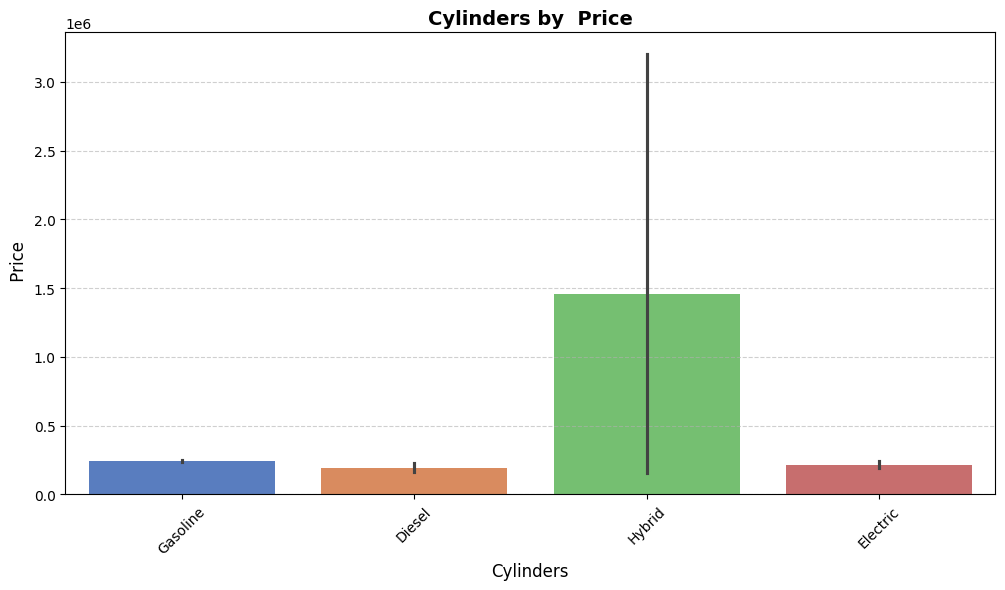

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df, x="Fuel Type", y="Price",estimator=np.mean,palette="muted")
# Title and Labels
plt.title("Cylinders by  Price", fontsize=14, fontweight="bold")
plt.xlabel("Cylinders", fontsize=12)
plt.ylabel(" Price", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

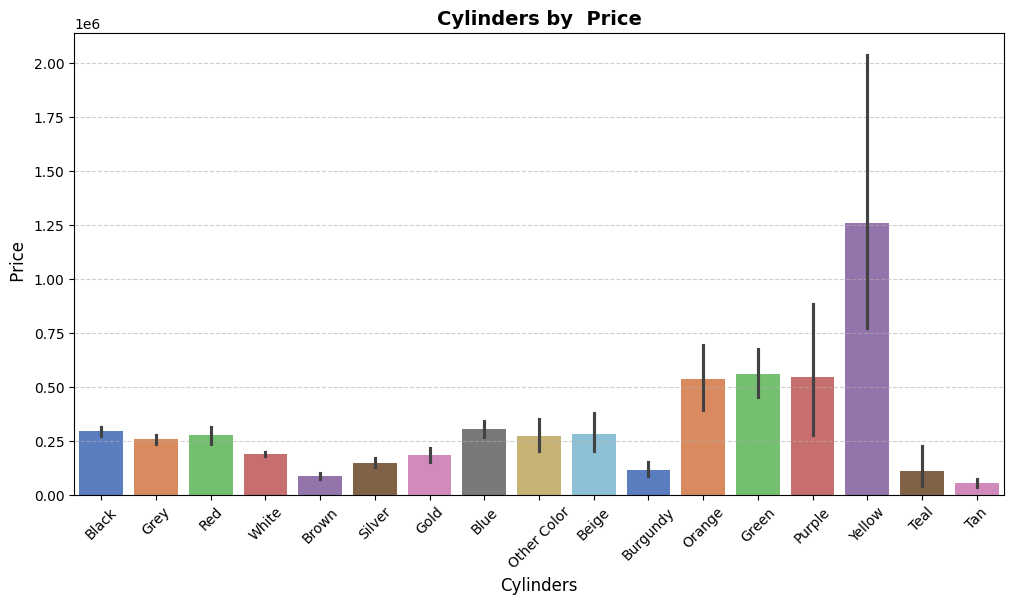

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df, x="Color", y="Price",estimator=np.mean,palette="muted")
# Title and Labels
plt.title("Cylinders by  Price", fontsize=14, fontweight="bold")
plt.xlabel("Cylinders", fontsize=12)
plt.ylabel(" Price", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

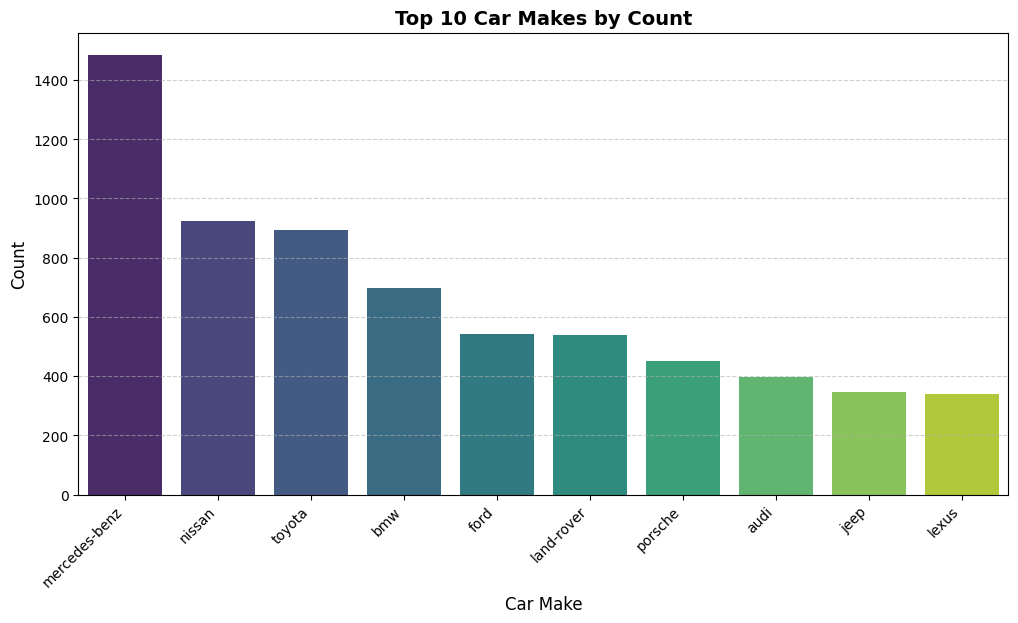

In [15]:
# Get the top 10 car makes by count
top_makes = df["Make"].value_counts().nlargest(10)

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df[df["Make"].isin(top_makes.index)],  
    x="Make",  
    order=top_makes.index,  # Ensure correct sorting
    palette="viridis"  # Nice color scheme
)

# Title and Labels
plt.title("Top 10 Car Makes by Count", fontsize=14, fontweight="bold")
plt.xlabel("Car Make", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")  # Rotate labels for better readability
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

#### Data prepration for ML

##### Lable Encoder

In [16]:
# Get all categorical (object) columns
categorical_columns = df.select_dtypes(include=['object']).columns

In [17]:
label_encoders = {}   # ✅ this is the fix

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le   # ✅ store each encoder

##### Feature selection

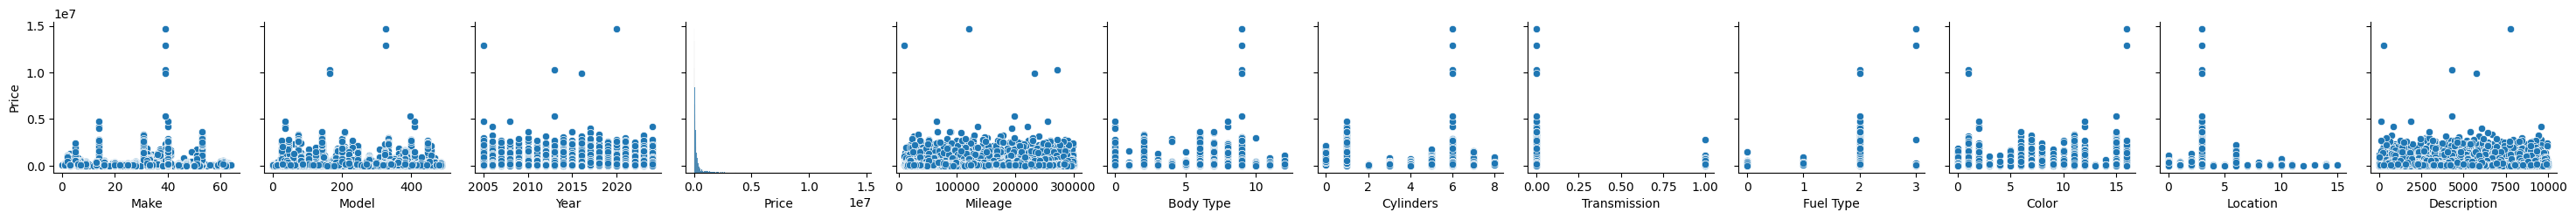

In [18]:
# Plot pairplot (Salary in usd vs. all numerical features)
sns.pairplot(df, y_vars=['Price'], height=2.5)
plt.show()

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

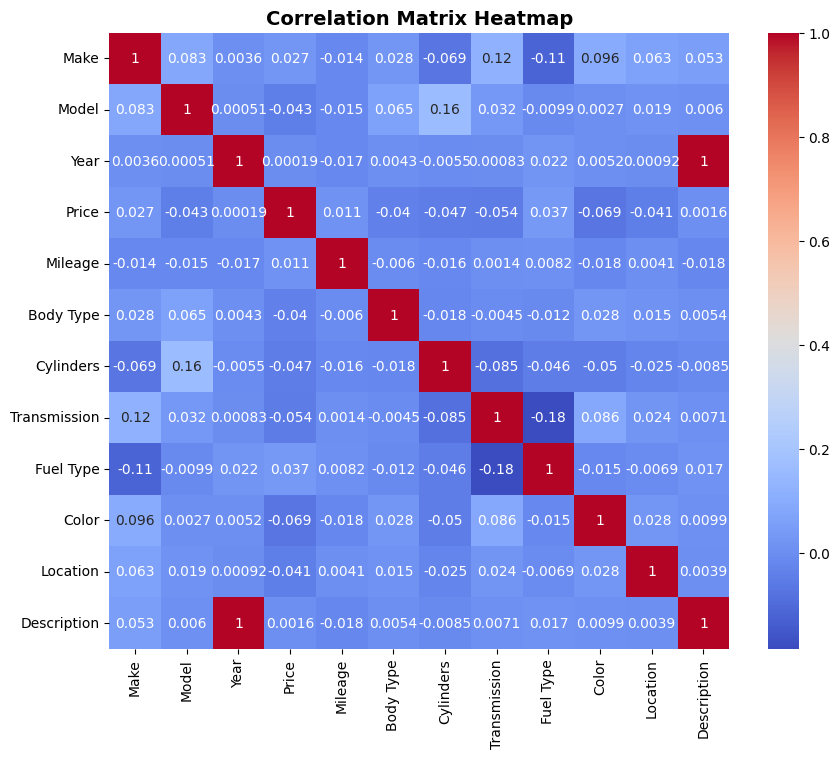

In [19]:
correlation_matrix=df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,cmap='coolwarm',annot=True)
plt.title("Correlation Matrix Heatmap", fontsize=14, fontweight='bold')

In [20]:
#slect feature and target
y=df['Price']
X=df.drop(['Price','Description'],axis=1)

##### Scaling

In [21]:
SC=StandardScaler()
X_scaler=SC.fit_transform(X)

##### Split data

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X_scaler,y,test_size=0.2,shuffle=True,random_state=44)

#### Model Training & Model Performance

##### LinearRegression

In [23]:
LR=LinearRegression()
LR.fit(X_train,y_train)
#data pred
y_pred_Test_LR=LR.predict(X_test)
y_pred_Train_LR=LR.predict(X_train)
#score
score_train_LR=LR.score(X_train, y_train)
score_test_LR=LR.score(X_test, y_test)
#cross validation
CV_LR=cross_val_score(LR,X,y,scoring='neg_mean_squared_error',cv=5)
CV_LR_mean=np.mean(CV_LR)
#Mean squared error 
MSR_Test_LR=mean_squared_error(y_test,y_pred_Test_LR)
MSR_Train_LR=mean_squared_error(y_train,y_pred_Train_LR)
#print metraces
print('Metraces for Linear Regression')
print('Train Score is:',score_train_LR)
print('Test Score is:',score_test_LR)
print('Mean Squared Error Train is:',MSR_Train_LR)
print('Mean Squared Error Test is:',MSR_Test_LR)
print('Cross Validation is:',CV_LR)
print('Mean Cross Validation is:',CV_LR_mean)

Metraces for Linear Regression
Train Score is: 0.015739063035501544
Test Score is: 0.01991815885874515
Mean Squared Error Train is: 231138944457.62387
Mean Squared Error Test is: 166179021187.20007
Cross Validation is: [-2.05963217e+11 -2.71980376e+11 -1.43851785e+11 -2.63499704e+11
 -2.08065040e+11]
Mean Cross Validation is: -218672024410.70175


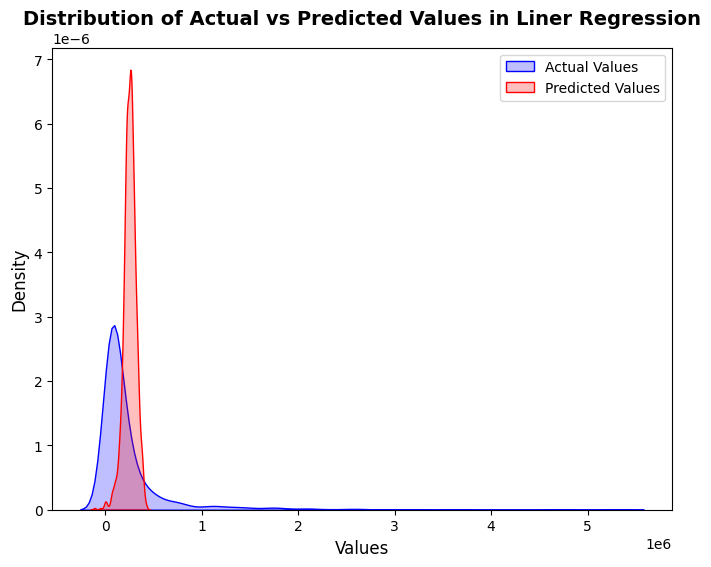

In [24]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_test, label='Actual Values', color='blue', fill=True)
sns.kdeplot(y_pred_Test_LR, label='Predicted Values', color='red', fill=True)
plt.xlabel('Values',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.title('Distribution of Actual vs Predicted Values in Liner Regression', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

##### RandomForestRegressor

In [25]:
RFR=RandomForestRegressor()
RFR.fit(X_train,y_train)
#data pred
y_pred_Test_RFR=RFR.predict(X_test)
y_pred_Train_RFR=RFR.predict(X_train)
#Score
score_train_RFR=RFR.score(X_train, y_train)
score_test_RFR=RFR.score(X_test, y_test)
#cross validation
CV_RFR=cross_val_score(RFR,X,y,scoring='neg_mean_squared_error',cv=5)
CV_RFR_mean=np.mean(CV_RFR)
#Mean squared error 
MSR_Test_RFR=mean_squared_error(y_test,y_pred_Test_RFR)
MSR_Train_RFR=mean_squared_error(y_train,y_pred_Train_RFR)
#print metraces
print('Metraces for RandomForestRegressor')
print('Train Score is:',score_train_RFR)
print('Test Score is:',score_test_RFR)
print('Mean Squared Error Train is:',MSR_Train_RFR)
print('Mean Squared Error Test is:',MSR_Test_RFR)
print('Cross Validation is:',CV_RFR)
print('Mean Cross Validation is:',CV_RFR_mean)

Metraces for RandomForestRegressor
Train Score is: 0.9501005677526067
Test Score is: 0.7336062737433877
Mean Squared Error Train is: 11718134557.150688
Mean Squared Error Test is: 45168726550.61716
Cross Validation is: [-8.84649124e+10 -6.63269766e+10 -4.22628074e+10 -1.38588713e+11
 -6.63173895e+10]
Mean Cross Validation is: -80392159884.28403


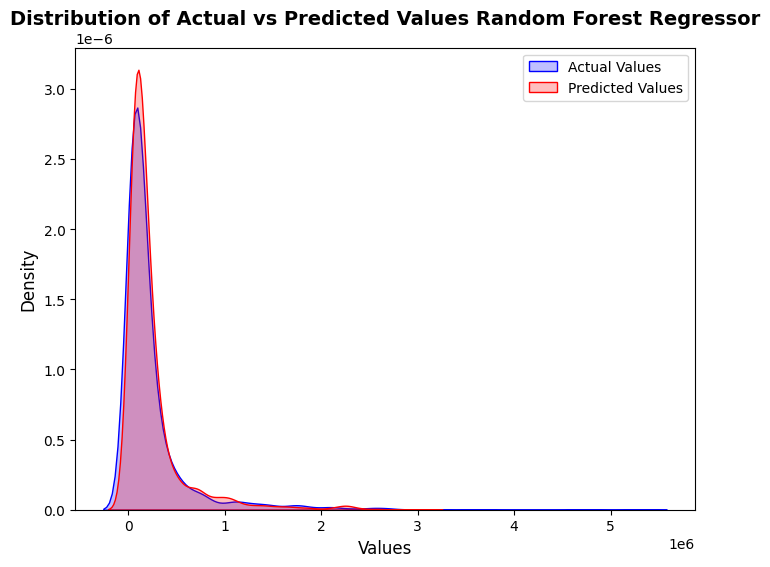

In [26]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_test, label='Actual Values', color='blue', fill=True)
sns.kdeplot(y_pred_Test_RFR, label='Predicted Values', color='red', fill=True)
plt.xlabel('Values',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.title('Distribution of Actual vs Predicted Values Random Forest Regressor', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

##### DecisionTreeRegressor

In [27]:
DTR=DecisionTreeRegressor()
DTR.fit(X_train,y_train)
#data pred
y_pred_Test_DTR=DTR.predict(X_test)
y_pred_Train_DTR=DTR.predict(X_train)
#score
score_train_DTR=DTR.score(X_train, y_train)
score_test_DTR=DTR.score(X_test, y_test)
#cross validation
CV_DTR=cross_val_score(DTR,X,y,scoring='neg_mean_squared_error',cv=5)
CV_DTR_mean=np.mean(CV_DTR)
#Mean squared error 
MSR_Test_DTR=mean_squared_error(y_test,y_pred_Test_DTR)
MSR_Train_DTR=mean_squared_error(y_train,y_pred_Train_DTR)
#print metraces
print('Metraces for DecisionTreeRegressor')
print('Train Score is:',score_train_DTR)
print('Test Score is:',score_test_DTR)
print('Mean Squared Error Train is:',MSR_Train_DTR)
print('Mean Squared Error Test is:',MSR_Test_DTR)
print('Cross Validation is:',CV_DTR)
print('Mean Cross Validation is:',CV_DTR_mean)

Metraces for DecisionTreeRegressor
Train Score is: 1.0
Test Score is: 0.5650708280571413
Mean Squared Error Train is: 0.0
Mean Squared Error Test is: 73744968068.24
Cross Validation is: [-9.96032266e+10 -7.02237342e+10 -8.63968941e+10 -1.69166321e+11
 -1.04167088e+11]
Mean Cross Validation is: -105911452886.4223


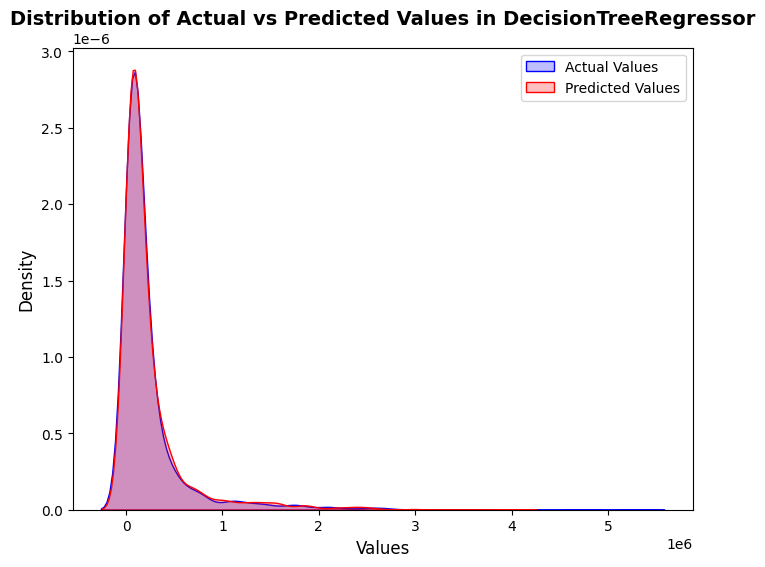

In [28]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_test, label='Actual Values', color='blue', fill=True)
sns.kdeplot(y_pred_Test_DTR, label='Predicted Values', color='red', fill=True)
plt.xlabel('Values',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.title('Distribution of Actual vs Predicted Values in DecisionTreeRegressor',fontsize=14, fontweight='bold')
plt.legend()
plt.show()

##### GradientBoostingRegressor

In [29]:
GBR = GradientBoostingRegressor()
GBR.fit(X_train, y_train)

y_pred_Test_GBR = GBR.predict(X_test)
y_pred_Train_GBR = GBR.predict(X_train)

# Score evaluation
score_train_GBR = GBR.score(X_train, y_train)
score_test_GBR = GBR.score(X_test, y_test)

# Cross-validation
CV_GBR = cross_val_score(GBR, X, y, scoring='neg_mean_squared_error', cv=5)
CV_GBR_mean = np.mean(CV_GBR)

# Mean Squared Error
MSR_Test_GBR = mean_squared_error(y_test, y_pred_Test_GBR)
MSR_Train_GBR = mean_squared_error(y_train, y_pred_Train_GBR)
# Print metrics
print('Metrics for GradientBoostingRegressor')
print('Train Score is:', score_train_GBR)
print('Test Score is:', score_test_GBR)
print('Mean Squared Error Train is:', MSR_Train_GBR)
print('Mean Squared Error Test is:', MSR_Test_GBR)
print('Cross Validation is:', CV_GBR)
print('Mean Cross Validation is:', CV_GBR_mean)

Metrics for GradientBoostingRegressor
Train Score is: 0.7309747945666274
Test Score is: 0.6601373358313485
Mean Squared Error Train is: 63176541586.76422
Mean Squared Error Test is: 57625845616.98932
Cross Validation is: [-8.07138963e+10 -8.76081636e+10 -5.30862185e+10 -1.45368409e+11
 -8.61120814e+10]
Mean Cross Validation is: -90577753807.44968


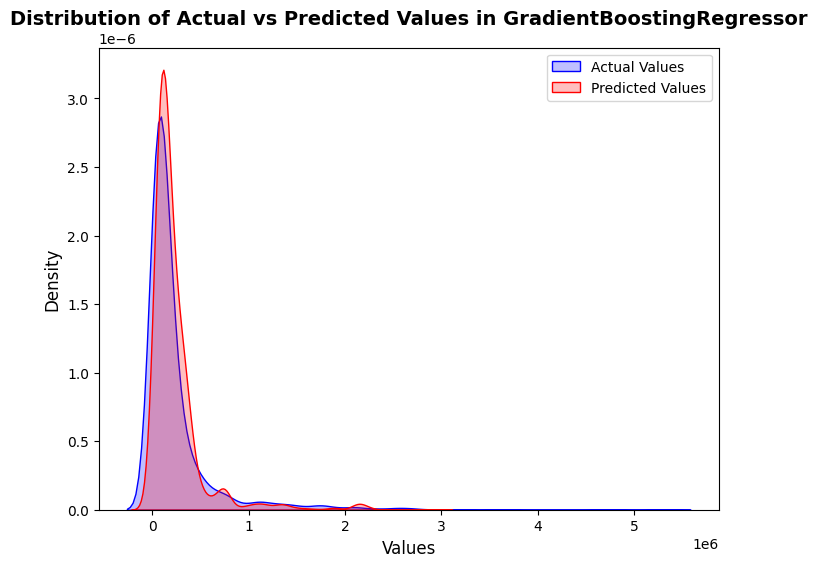

In [30]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_test, label='Actual Values', color='blue', fill=True)
sns.kdeplot(y_pred_Test_GBR, label='Predicted Values', color='red', fill=True)
plt.xlabel('Values',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.title('Distribution of Actual vs Predicted Values in GradientBoostingRegressor',fontsize=14, fontweight='bold')
plt.legend()
plt.show()

##### XGBRegressor

In [31]:
# Initialize and fit XGBoost Regressor
XGB= xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
XGB.fit(X_train, y_train)

# Predictions
y_pred_Test_XGB = XGB.predict(X_test)
y_pred_Train_XGB = XGB.predict(X_train)

# Score evaluation
score_train_XGB = XGB.score(X_train, y_train)
score_test_XGB = XGB.score(X_test, y_test)

# Cross-validation
CV_XGB = cross_val_score(XGB, X, y, scoring='neg_mean_squared_error', cv=5)
CV_XGB_mean = np.mean(CV_XGB)

# Mean Squared Error
MSR_Test_XGB = mean_squared_error(y_test, y_pred_Test_XGB)
MSR_Train_XGB = mean_squared_error(y_train, y_pred_Train_XGB)


# Print metrics
print('Metrics for XGBoost Regression')
print('Train Score is:', score_train_XGB)
print('Test Score is:', score_test_XGB)
print('Mean Squared Error Train is:', MSR_Train_XGB)
print('Mean Squared Error Test is:', MSR_Test_XGB)
print('Cross Validation is:', CV_XGB)
print('Mean Cross Validation is:', CV_XGB_mean)

Metrics for XGBoost Regression
Train Score is: 0.9533453583717346
Test Score is: 0.7220180034637451
Mean Squared Error Train is: 10956140544.0
Mean Squared Error Test is: 47133597696.0
Cross Validation is: [-1.11809642e+11 -6.11236454e+10 -4.07353631e+10 -1.03425614e+11
 -5.57588357e+10]
Mean Cross Validation is: -74570620108.8


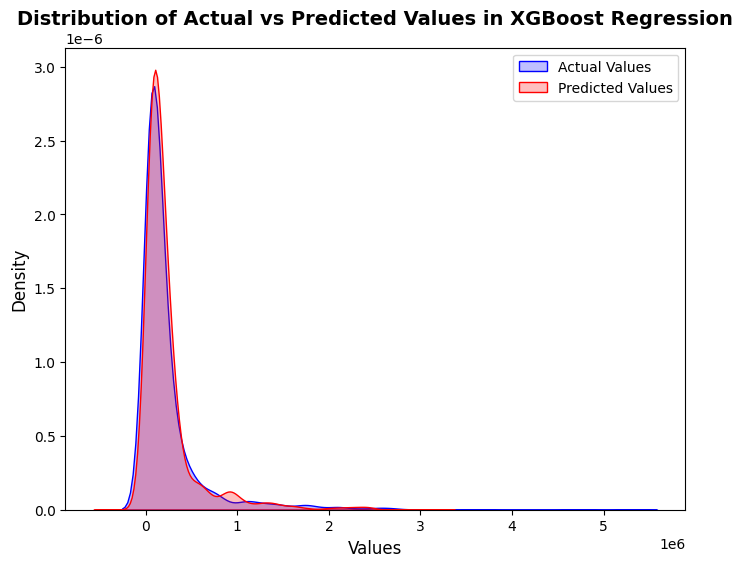

In [32]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_test, label='Actual Values', color='blue', fill=True)
sns.kdeplot(y_pred_Test_XGB, label='Predicted Values', color='red', fill=True)
plt.xlabel('Values',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.title('Distribution of Actual vs Predicted Values in XGBoost Regression',fontsize=14, fontweight='bold')
plt.legend()
plt.show()

##### Compare Models with Multiple Metrics

In [33]:
# Define metrics for each model
models = ["Linear Regression","Random Forest Regressor", "Decision Tree Regressor",'Gradient Boosting Regressor','XGBoost Regression']

train_scores = [score_train_LR, score_train_RFR, score_train_DTR, score_train_GBR, score_train_XGB]
test_scores = [score_test_LR, score_test_RFR, score_test_DTR, score_test_GBR, score_test_XGB]
cv_scores = [CV_LR_mean, CV_RFR_mean, CV_DTR_mean, CV_GBR_mean, CV_XGB_mean]
mse_train = [MSR_Train_LR, MSR_Train_RFR, MSR_Train_DTR, MSR_Train_GBR, MSR_Train_XGB]
mse_test = [MSR_Test_LR, MSR_Test_RFR, MSR_Test_DTR, MSR_Test_GBR, MSR_Test_XGB]

# Create a DataFrame to store the results
df_comparison = pd.DataFrame({
    "Model": models,
    "Train Score": train_scores,
    "Test Score": test_scores,
    "CV Score": cv_scores,
    "MSE Train": mse_train,
    "MSE Test": mse_test
})

# Sort models by Test Score (Descending Order)
df_comparison = df_comparison.sort_values(by="Test Score", ascending=False)

# Print the table
print("Model Performance Comparison:\n")
print(df_comparison.to_string())

Model Performance Comparison:

                         Model  Train Score  Test Score      CV Score     MSE Train      MSE Test
1      Random Forest Regressor     0.950101    0.733606 -8.039216e+10  1.171813e+10  4.516873e+10
4           XGBoost Regression     0.953345    0.722018 -7.457062e+10  1.095614e+10  4.713360e+10
3  Gradient Boosting Regressor     0.730975    0.660137 -9.057775e+10  6.317654e+10  5.762585e+10
2      Decision Tree Regressor     1.000000    0.565071 -1.059115e+11  0.000000e+00  7.374497e+10
0            Linear Regression     0.015739    0.019918 -2.186720e+11  2.311389e+11  1.661790e+11


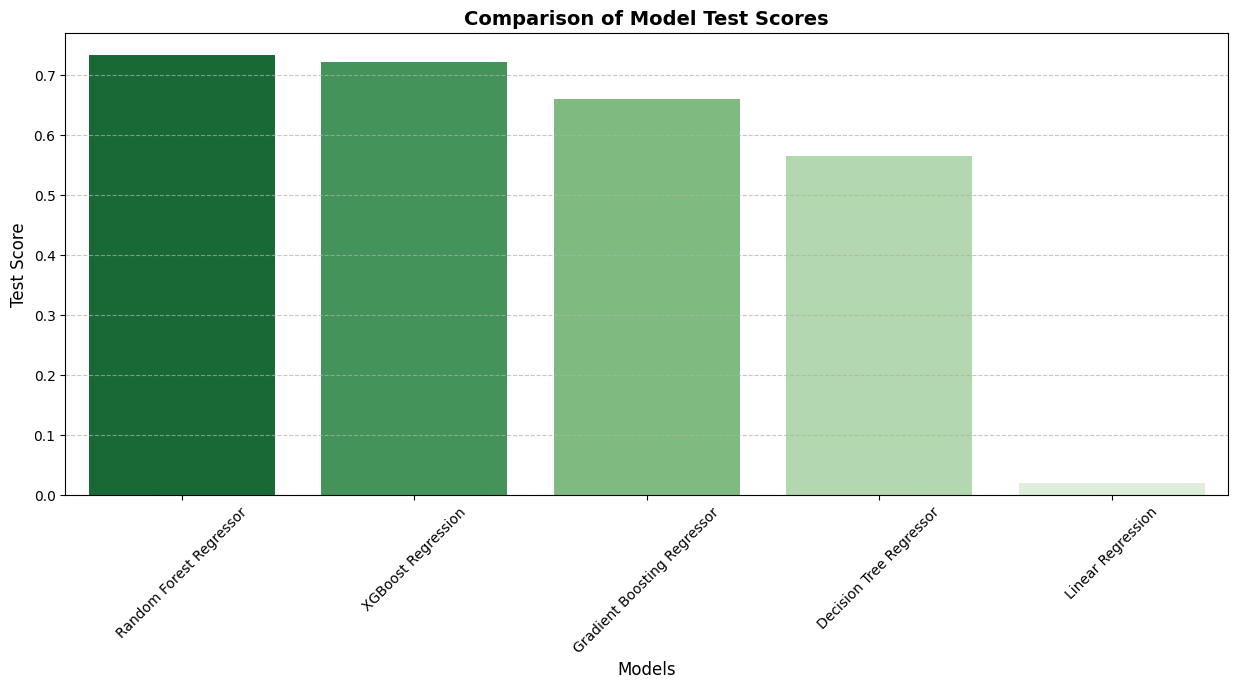

In [34]:
# Set plot style
plt.figure(figsize=(15, 6))
sns.barplot(x=df_comparison["Model"], y=df_comparison["Test Score"], palette="Greens_r")

# Formatting the plot
plt.xlabel("Models", fontsize=12)
plt.ylabel("Test Score", fontsize=12)
plt.title("Comparison of Model Test Scores", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
# Show the plot
plt.show()

##### Saving best the model details

In [35]:
import joblib

artifacts = {
    "model": XGB,
    "scaler": SC,
    "label_encoders": label_encoders,
    "categorical_columns": categorical_columns,
    "feature_columns": X.columns.tolist()
}

joblib.dump(artifacts, "stacking_model.pkl")


['stacking_model.pkl']